In [32]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [33]:
import pandas as pd
import zipfile
import os

# Paths to zip files
zip_files = ["/kaggle/input/walmart-recruiting-store-sales-forecasting/features.csv.zip", 
             "/kaggle/input/walmart-recruiting-store-sales-forecasting/test.csv.zip", 
             "/kaggle/input/walmart-recruiting-store-sales-forecasting/train.csv.zip"]

# Unzip all files
for zip_file in zip_files:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("data")

# Load datasets
features = pd.read_csv("data/features.csv")
stores = pd.read_csv("/kaggle/input/walmart-recruiting-store-sales-forecasting/stores.csv")
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# Quick data check
print(f"Features Shape: {features.shape}")
print(f"Stores Shape: {stores.shape}")
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")

Features Shape: (8190, 12)
Stores Shape: (45, 3)
Train Shape: (421570, 5)
Test Shape: (115064, 4)


In [34]:
# Merge feature and store data with train and test sets
train = train.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
train = train.merge(stores, how='left', on='Store')

test = test.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
test = test.merge(stores, how='left', on='Store')


In [35]:
# Ensure 'Date' columns are in datetime format
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

In [36]:
# Replace missing values in markdown-related columns with zero
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
for col in markdown_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)


In [37]:
# Add new columns for year, month, week, and weekday
for dataset in [train, test]:
    dataset['Year'] = dataset['Date'].dt.year
    dataset['Month'] = dataset['Date'].dt.month
    dataset['Week'] = dataset['Date'].dt.isocalendar().week
    dataset['DayOfWeek'] = dataset['Date'].dt.dayofweek


In [38]:
# Add binary flags for major US holidays
special_holidays = {
    "SuperBowl": ["2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"],
    "LaborDay": ["2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"],
    "Thanksgiving": ["2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"],
    "Christmas": ["2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"]
}
for name, date_list in special_holidays.items():
    for dataset in [train, test]:
        dataset[name] = dataset['Date'].isin(pd.to_datetime(date_list)).astype(int)


In [39]:
# Preview the first few rows of the processed datasets
print(train.head())
print(test.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     1 2010-02-12      46039.49       True        38.51       2.548   
2      1     1 2010-02-19      41595.55      False        39.93       2.514   
3      1     1 2010-02-26      19403.54      False        46.63       2.561   
4      1     1 2010-03-05      21827.90      False        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  ...  Type    Size  Year  Month Week  \
0        0.0        0.0        0.0  ...     A  151315  2010      2    5   
1        0.0        0.0        0.0  ...     A  151315  2010      2    6   
2        0.0        0.0        0.0  ...     A  151315  2010      2    7   
3        0.0        0.0        0.0  ...     A  151315  2010      2    8   
4        0.0        0.0        0.0  ...     A  151315  2010      3    9   

   DayOfWeek  SuperBowl  LaborDay  Thanksgiving  Christmas  
0          4 

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

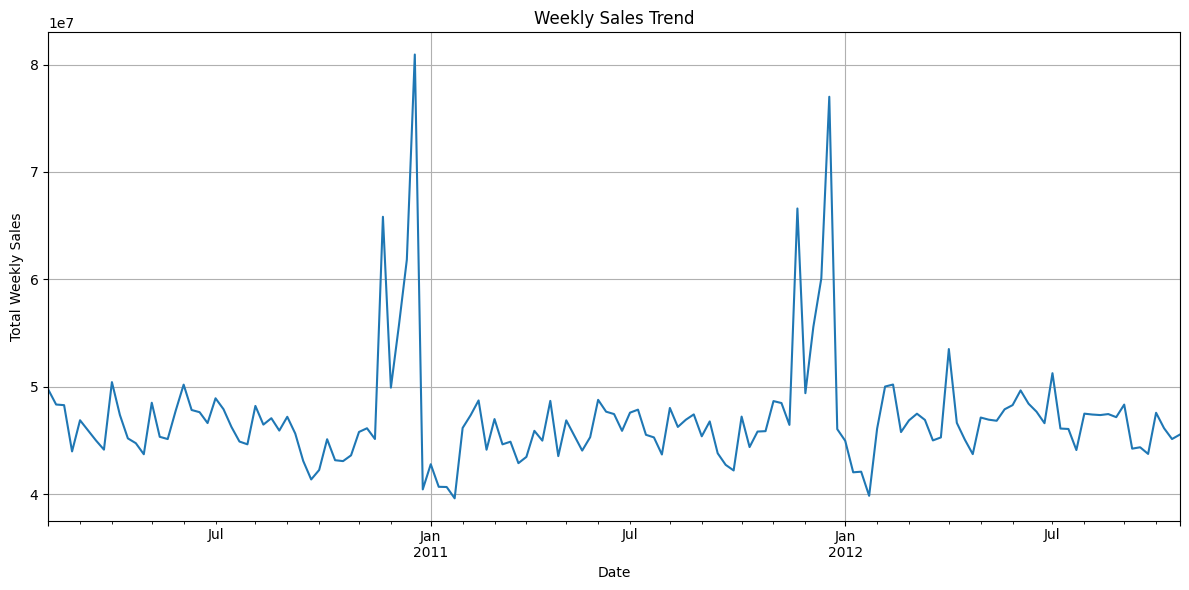

In [41]:
# Line plot showing total weekly sales progression over time
plt.figure(figsize=(12, 6))
train.groupby('Date')['Weekly_Sales'].sum().plot(title='Weekly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

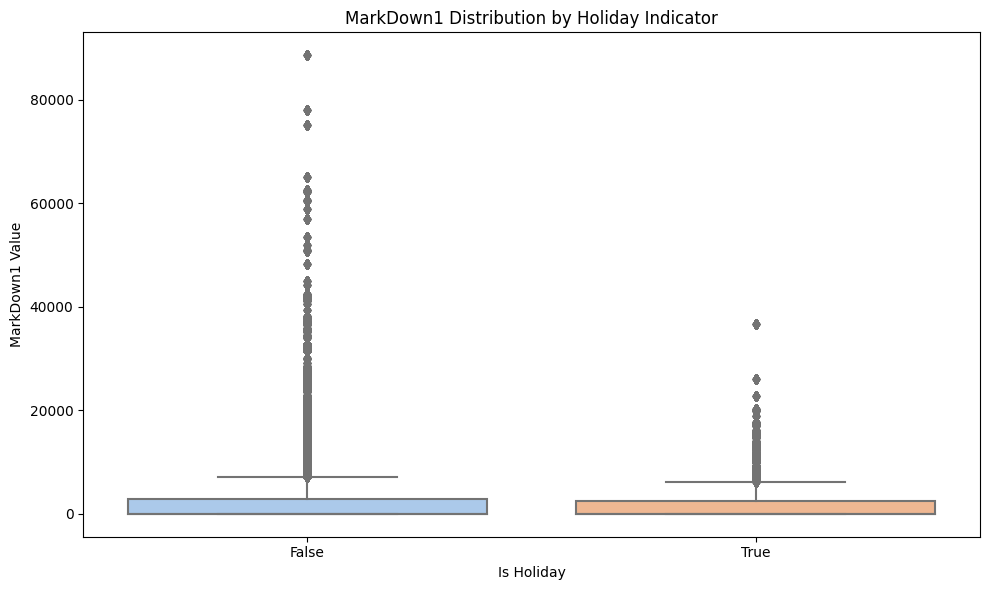

In [42]:
# Box plot showing distribution of MarkDown1 for holiday vs non-holiday weeks
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='IsHoliday', y='MarkDown1', palette='pastel')
plt.title('MarkDown1 Distribution by Holiday Indicator')
plt.xlabel('Is Holiday')
plt.ylabel('MarkDown1 Value')
plt.tight_layout()
plt.show()

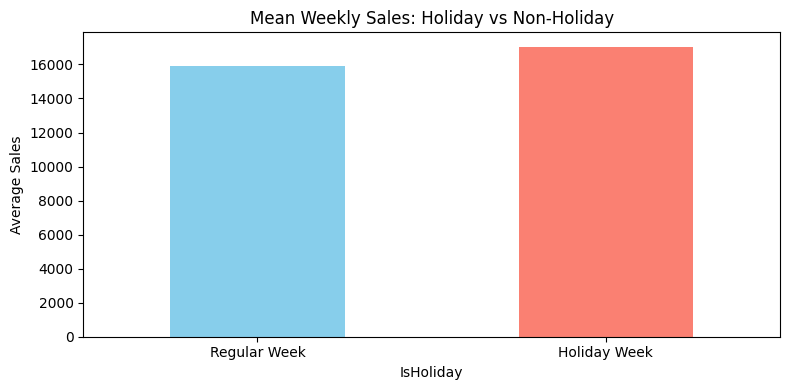

In [43]:
# Bar chart comparing average weekly sales during holidays and regular weeks
avg_sales_by_holiday = train.groupby('IsHoliday')['Weekly_Sales'].mean()

plt.figure(figsize=(8, 4))
avg_sales_by_holiday.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Mean Weekly Sales: Holiday vs Non-Holiday')
plt.xticks([0, 1], ['Regular Week', 'Holiday Week'], rotation=0)
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()


In [44]:
# List of predictors to use in the model
input_columns = [
    'Store', 'Dept', 'Type', 'Size', 'Temperature', 'Fuel_Price',
    'CPI', 'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week', 'DayOfWeek',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'SuperBowl', 'LaborDay', 'Thanksgiving', 'Christmas'
]

# Column we want to predict
target_column = 'Weekly_Sales'


In [45]:
#Handle Categorical Variables
# Convert object-type columns to categorical for better handling
for feature in ['Type', 'IsHoliday']:
    train[feature] = train[feature].astype('category')
    test[feature] = test[feature].astype('category')


In [46]:
from sklearn.model_selection import train_test_split

# Extract features and labels from training data
X_full = train[input_columns]
y_full = train[target_column]

# Reserve 20% of the data for validation (no shuffle for time-aware split)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_full, y_full, test_size=0.2, shuffle=False
)


In [47]:
import numpy as np

# Define a custom evaluation metric that penalizes holiday errors more
def holiday_weighted_rmse(actual_values, predicted_values, holiday_flags):
    # Use higher weight for holidays (5x) and normal weight (1x) otherwise
    weight_array = np.where(holiday_flags, 5, 1)
    squared_diff = (actual_values - predicted_values) ** 2
    weighted_error = np.sum(weight_array * squared_diff) / np.sum(weight_array)
    return np.sqrt(weighted_error)

# Convert holiday column to boolean flags for validation set
holiday_flags_validation = X_valid['IsHoliday'].astype(bool).values


# Training

In [48]:
import lightgbm as lgb


In [49]:
!pip install lightgbm


In [50]:
# Create LightGBM dataset objects for training and validation
train_dataset = lgb.Dataset(X_train, label=y_train)
valid_dataset = lgb.Dataset(X_valid, label=y_valid, reference=train_dataset)


In [51]:
# Specify LightGBM parameters for regression task
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05
}


In [52]:
# Train the model with early stopping and periodic logging
lgb_model = lgb.train(
    lgb_params,
    train_dataset,
    valid_sets=[valid_dataset],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 9945.39
Early stopping, best iteration is:
[130]	valid_0's rmse: 9765.55


In [53]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Generate predictions using the trained model
predicted_sales = lgb_model.predict(X_valid)

# Calculate Root Mean Squared Error (RMSE)
root_mse = np.sqrt(mean_squared_error(y_valid, predicted_sales))

# Calculate Mean Absolute Error (MAE)
mean_abs_error = mean_absolute_error(y_valid, predicted_sales)

# Compute R² Score to assess variance explanation
r_squared = r2_score(y_valid, predicted_sales)

# Display the evaluation results
print(f"Validation RMSE: {root_mse:.2f}")
print(f"Validation MAE: {mean_abs_error:.2f}")
print(f"Validation R² Score: {r_squared:.2f}")


Validation RMSE: 9765.55
Validation MAE: 5753.77
Validation R² Score: 0.74


In [54]:
def objective(trial):
    # Define hyperparameter space
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'verbosity': -1
    }

    # LightGBM Dataset
    train_set = lgb.Dataset(X_train, label=y_train)
    val_set = lgb.Dataset(X_valid, label=y_valid, reference=train_set)

    # Train model using callbacks
    model = lgb.train(
        params,
        train_set,
        valid_sets=[val_set],
        num_boost_round=1000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(100)
        ]
    )

    # Predict and compute RMSE
    preds = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    return rmse


In [55]:
!pip install optuna


In [56]:
import optuna


In [57]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=600)


[I 2025-07-08 17:39:10,155] A new study created in memory with name: no-name-6fc7299c-f35c-4e09-ba02-6cb3b8098e78


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 9215.57
[200]	valid_0's rmse: 9005.36
Early stopping, best iteration is:
[238]	valid_0's rmse: 8930.91


[I 2025-07-08 17:39:15,521] Trial 0 finished with value: 8930.906361041574 and parameters: {'learning_rate': 0.07385810453612413, 'num_leaves': 68, 'max_depth': 10, 'min_child_samples': 89, 'subsample': 0.7580656754562453, 'colsample_bytree': 0.9256813628285172, 'reg_alpha': 1.4278679651858728, 'reg_lambda': 0.4626628288173923}. Best is trial 0 with value: 8930.906361041574.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 9722.2
[200]	valid_0's rmse: 9603.64
Early stopping, best iteration is:
[192]	valid_0's rmse: 9516.41


[I 2025-07-08 17:39:18,872] Trial 1 finished with value: 9516.414021861945 and parameters: {'learning_rate': 0.175399038821708, 'num_leaves': 124, 'max_depth': 5, 'min_child_samples': 23, 'subsample': 0.5537134613835493, 'colsample_bytree': 0.9372232742254194, 'reg_alpha': 4.261025115378725, 'reg_lambda': 1.2861657732856613}. Best is trial 0 with value: 8930.906361041574.


...

[I 2025-07-08 17:48:29,453] Trial 47 finished with value: 8124.9511316890075 and parameters: {'learning_rate': 0.13864184910232732, 'num_leaves': 125, 'max_depth': 15, 'min_child_samples': 70, 'subsample': 0.8787540623870597, 'colsample_bytree': 0.6240754233527995, 'reg_alpha': 0.8488040028321342, 'reg_lambda': 3.806764399537255}. Best is trial 22 with value: 8022.509307053613.


Early stopping, best iteration is:
[89]	valid_0's rmse: 8124.95
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 10743.8
[200]	valid_0's rmse: 8666.96
[300]	valid_0's rmse: 8258.94
[400]	valid_0's rmse: 8130.58
[500]	valid_0's rmse: 8098.64
[600]	valid_0's rmse: 8089.57
Early stopping, best iteration is:
[562]	valid_0's rmse: 8083.88


[I 2025-07-08 17:48:50,545] Trial 48 finished with value: 8083.883135990457 and parameters: {'learning_rate': 0.01967912015648235, 'num_leaves': 138, 'max_depth': 13, 'min_child_samples': 50, 'subsample': 0.8328174405263306, 'colsample_bytree': 0.5213953470955263, 'reg_alpha': 2.934300043384954, 'reg_lambda': 4.690162459471594}. Best is trial 22 with value: 8022.509307053613.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 9400.45
[200]	valid_0's rmse: 8483.7
[300]	valid_0's rmse: 8383.96
[400]	valid_0's rmse: 8369.4
Early stopping, best iteration is:
[353]	valid_0's rmse: 8358.51


[I 2025-07-08 17:49:01,066] Trial 49 finished with value: 8358.511232992458 and parameters: {'learning_rate': 0.030271239430222682, 'num_leaves': 133, 'max_depth': 8, 'min_child_samples': 62, 'subsample': 0.7231479806203739, 'colsample_bytree': 0.6027918181592435, 'reg_alpha': 0.30542936157788075, 'reg_lambda': 3.2421274301339977}. Best is trial 22 with value: 8022.509307053613.


In [58]:
best_params = study.best_params
best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'verbosity': -1
})

final_train_set = lgb.Dataset(X_train, label=y_train)
final_val_set = lgb.Dataset(X_valid, label=y_valid, reference=final_train_set)

final_model = lgb.train(
    best_params,
    final_train_set,
    valid_sets=[final_val_set],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(100)
    ]
)


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 9427.48
[200]	valid_0's rmse: 8283.15
[300]	valid_0's rmse: 8075.81
[400]	valid_0's rmse: 8023.7
Early stopping, best iteration is:
[396]	valid_0's rmse: 8022.51


In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predictions on validation data
y_val_pred = final_model.predict(X_valid)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_valid, y_val_pred))

# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_valid, y_val_pred)

# R² Score
r2 = r2_score(y_valid, y_val_pred)

print(f"Validation RMSE: {rmse:.2f}")
print(f"Validation MAE: {mae:.2f}")
print(f"Validation R² Score: {r2:.2f}")

Validation RMSE: 8022.51
Validation MAE: 4556.71
Validation R² Score: 0.82


In [60]:
!pip install dagshub mlflow
import dagshub
import mlflow
dagshub.init(repo_owner='TamariToradze', repo_name='ML-Final', mlflow=True)

Initialized MLflow to track repo "TamariToradze/ML-Final"

Repository TamariToradze/ML-Final initialized!

# MLflow

In [61]:
!pip install mlflow


In [72]:
# -------------------------------
# 📌 IMPORTS
# -------------------------------
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import mlflow
import mlflow.lightgbm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


os.environ['MLFLOW_TRACKING_USERNAME'] = 'TamariToradze'  # Replace with your username
os.environ['MLFLOW_TRACKING_PASSWORD'] = 'fdc456041a62b7eaf1e2783a161db232ae5f18f6'  # Replace with your token
mlflow.set_tracking_uri('https://dagshub.com/TamariToradze/ML-Final.mlflow')  # Replace with your DagsHub repo


from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

# Example: Add a fake categorical column for demonstration
X['Region'] = ['A', 'B', 'C', 'D'] * (len(X) // 4) + ['A'] * (len(X) % 4)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# ✅ FIX: Convert object columns to category
# -------------------------------
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')

print("✅ Data types after conversion:\n", X_train.dtypes)


def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'verbosity': -1
    }

    train_set = lgb.Dataset(X_train, label=y_train)
    val_set = lgb.Dataset(X_valid, label=y_valid, reference=train_set)

    model = lgb.train(
        params,
        train_set,
        valid_sets=[val_set],
        num_boost_round=1000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(100)
        ]
    )

    preds = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    return rmse

# -------------------------------
# 📌 Start MLflow experiment
# -------------------------------
mlflow.set_experiment("LightGBM_Optuna_Regression")

with mlflow.start_run(run_name="LightGBM_Optuna_DagsHub_Run"):
    # 🔍 Run Optuna
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50, timeout=600)

    best_params = study.best_params
    best_params.update({
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1
    })

    mlflow.log_params(best_params)

    # 🔁 Train final model
    final_train_set = lgb.Dataset(X_train, label=y_train)
    final_val_set = lgb.Dataset(X_valid, label=y_valid, reference=final_train_set)

    final_model = lgb.train(
        best_params,
        final_train_set,
        valid_sets=[final_val_set],
        num_boost_round=1000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(100)
        ]
    )

    # 📈 Evaluate
    y_val_pred = final_model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, y_val_pred))
    mae = mean_absolute_error(y_valid, y_val_pred)
    r2 = r2_score(y_valid, y_val_pred)

    print(f"✅ Validation RMSE: {rmse:.4f}")
    print(f"✅ Validation MAE: {mae:.4f}")
    print(f"✅ Validation R² Score: {r2:.4f}")

    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)

    # ✅ SAVE the model locally + log to DagsHub
    model_path = "lgb_model"
    mlflow.lightgbm.save_model(final_model, model_path)
    mlflow.log_artifact(model_path)

print("🚀 All done! View your run on DagsHub MLflow UI.")


[I 2025-07-08 19:10:39,318] A new study created in memory with name: no-name-302cd9b7-abb8-4ba0-9665-5aa5e8f881a0


✅ Data types after conversion:
 MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
Region        category
dtype: object
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.44754
[200]	valid_0's rmse: 0.441849
Early stopping, best iteration is:
[183]	valid_0's rmse: 0.44133


[I 2025-07-08 19:10:40,478] Trial 0 finished with value: 0.44132981866334725 and parameters: {'learning_rate': 0.11779912762661775, 'num_leaves': 123, 'max_depth': 14, 'min_child_samples': 50, 'subsample': 0.8511487423199864, 'colsample_bytree': 0.926565677024026, 'reg_alpha': 3.1068932616320155, 'reg_lambda': 3.358819982591099}. Best is trial 0 with value: 0.44132981866334725.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.4487
[200]	valid_0's rmse: 0.443735


[I 2025-07-08 19:10:41,412] Trial 1 finished with value: 0.4435062389335357 and parameters: {'learning_rate': 0.179558129413602, 'num_leaves': 80, 'max_depth': 11, 'min_child_samples': 69, 'subsample': 0.6730969154897545, 'colsample_bytree': 0.7442112362292754, 'reg_alpha': 2.0125796864866192, 'reg_lambda': 1.4613277641960654}. Best is trial 0 with value: 0.44132981866334725.


...

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.464802
[200]	valid_0's rmse: 0.444435
[300]	valid_0's rmse: 0.438824
[400]	valid_0's rmse: 0.436104
[500]	valid_0's rmse: 0.434878
[600]	valid_0's rmse: 0.4341
[700]	valid_0's rmse: 0.433892
Early stopping, best iteration is:
[684]	valid_0's rmse: 0.433735


[I 2025-07-08 19:12:02,781] Trial 48 finished with value: 0.43373523176913986 and parameters: {'learning_rate': 0.05099195893936907, 'num_leaves': 103, 'max_depth': 11, 'min_child_samples': 34, 'subsample': 0.9747820698204536, 'colsample_bytree': 0.7502917324386642, 'reg_alpha': 4.133733497669748, 'reg_lambda': 1.165394827203197}. Best is trial 40 with value: 0.4282479949551542.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.530355
[200]	valid_0's rmse: 0.468498
[300]	valid_0's rmse: 0.453093
[400]	valid_0's rmse: 0.445977
[500]	valid_0's rmse: 0.441442
[600]	valid_0's rmse: 0.438548
[700]	valid_0's rmse: 0.436422
[800]	valid_0's rmse: 0.434929
[900]	valid_0's rmse: 0.433761
[1000]	valid_0's rmse: 0.432883
Did not meet early stopping. Best iteration is:
[999]	valid_0's rmse: 0.432878


[I 2025-07-08 19:12:06,616] Trial 49 finished with value: 0.43287768153672873 and parameters: {'learning_rate': 0.022813011053802453, 'num_leaves': 76, 'max_depth': 14, 'min_child_samples': 14, 'subsample': 0.9159196204827366, 'colsample_bytree': 0.8187377743315352, 'reg_alpha': 3.8674442421038937, 'reg_lambda': 0.8344395059844929}. Best is trial 40 with value: 0.4282479949551542.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.459223
[200]	valid_0's rmse: 0.44131
[300]	valid_0's rmse: 0.435524
[400]	valid_0's rmse: 0.43236
[500]	valid_0's rmse: 0.430236
[600]	valid_0's rmse: 0.429732
[700]	valid_0's rmse: 0.428954
[800]	valid_0's rmse: 0.428514
[900]	valid_0's rmse: 0.428303
Early stopping, best iteration is:
[895]	valid_0's rmse: 0.428248
✅ Validation RMSE: 0.4282
✅ Validation MAE: 0.2786
✅ Validation R² Score: 0.8600
🏃 View run LightGBM_Optuna_DagsHub_Run at: https://dagshub.com/TamariToradze/ML-Final.mlflow/#/experiments/1/runs/3786c5a64d6e44e69a7c0805fa6fd5ef
🧪 View experiment at: https://dagshub.com/TamariToradze/ML-Final.mlflow/#/experiments/1
🚀 All done! View your run on DagsHub MLflow UI.


In [66]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import mlflow
import mlflow.lightgbm
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import BaseEstimator

os.environ['MLFLOW_TRACKING_USERNAME'] = 'TamariToradze'  # Replace with your DagsHub username
os.environ['MLFLOW_TRACKING_PASSWORD'] = 'fdc456041a62b7eaf1e2783a161db232ae5f18f6'     # Replace with your DagsHub token
mlflow.set_tracking_uri('https://dagshub.com/TamariToradze/ML-Final.mlflow')  # Replace with your repo URL


def create_pipeline():
    numeric_features = [
        'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
        'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
    ]
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_features = [
        'Type', 'IsHoliday', 'SuperBowl', 'LaborDay',
        'Thanksgiving', 'Christmas'
    ]
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('lgbm', lgb.LGBMRegressor())
    ])

    return pipeline


def load_and_preprocess_data():
    base_path = "/kaggle/input/walmart-recruiting-store-sales-forecasting/"

    features = pd.read_csv(base_path + "features.csv.zip")
    stores = pd.read_csv(base_path + "stores.csv")
    train = pd.read_csv(base_path + "train.csv.zip")

    train = train.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
    train = train.merge(stores, how='left', on='Store')

    train['Date'] = pd.to_datetime(train['Date'])
    train['Year'] = train['Date'].dt.year
    train['Month'] = train['Date'].dt.month
    train['Week'] = train['Date'].dt.isocalendar().week
    train['DayOfWeek'] = train['Date'].dt.dayofweek

    special_holidays = {
        "SuperBowl": ["2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"],
        "LaborDay": ["2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"],
        "Thanksgiving": ["2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"],
        "Christmas": ["2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"]
    }

    for name, dates in special_holidays.items():
        train[name] = train['Date'].isin(pd.to_datetime(dates)).astype(int)

    train = train.drop(['Date', 'Store', 'Dept'], axis=1)

    return train

def train_pipeline(pipeline, params, train_df):
    X = train_df.drop('Weekly_Sales', axis=1)
    y = train_df['Weekly_Sales']

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline.set_params(**params)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    return pipeline, y_val, y_pred, mse, rmse, mae, r2

def main():
    experiment_name = "walmart_sales_prediction2"
    mlflow.set_experiment(experiment_name)

    train_df = load_and_preprocess_data()
    pipeline = create_pipeline()

    params = {
        'lgbm__objective': 'regression',
        'lgbm__metric': 'rmse',
        'lgbm__boosting_type': 'gbdt',
        'lgbm__num_leaves': 31,
        'lgbm__learning_rate': 0.05,
        'lgbm__feature_fraction': 0.9,
        'lgbm__bagging_fraction': 0.8,
        'lgbm__bagging_freq': 5,
        'lgbm__random_state': 42
    }

    with mlflow.start_run() as run:
        # Log parameters
        mlflow.log_params(params)

        # Train model and get metrics
        trained_pipeline, y_val, y_pred, mse, rmse, mae, r2 = train_pipeline(
            pipeline, params, train_df
        )

        # Log metrics
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)

        # Save and log the complete pipeline
        pipeline_path = "/kaggle/working/model_pipeline.pkl"
        joblib.dump(trained_pipeline, pipeline_path)
        mlflow.log_artifact(pipeline_path)

        # Feature importance plot
        fig, ax = plt.subplots(figsize=(10, 8))
        lgb.plot_importance(trained_pipeline.named_steps['lgbm'], ax=ax)
        plt.tight_layout()
        plt.savefig('/kaggle/working/feature_importance.png')
        mlflow.log_artifact('/kaggle/working/feature_importance.png')
        plt.close()

        # Residuals plot
        fig, ax = plt.subplots(figsize=(10, 6))
        residuals = y_val - y_pred
        plt.scatter(y_pred, residuals)
        plt.axhline(0, color='red', linestyle='--')
        plt.xlabel("Predicted Sales")
        plt.ylabel("Residuals")
        plt.title("Residuals vs Predicted Sales")
        plt.savefig('/kaggle/working/residuals_vs_predicted.png')
        mlflow.log_artifact('/kaggle/working/residuals_vs_predicted.png')
        plt.close()

        print(f"Run ID: {run.info.run_id}")
        print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.2f}")

# -------------------------------
# 📌 ENTRY POINT
# -------------------------------
if __name__ == "__main__":
    main()

Run ID: 91ae239c831d4dec863f5ba1a0e036c2
RMSE: 21755.56 | MAE: 14317.12 | R2: 0.09
🏃 View run sassy-roo-316 at: https://dagshub.com/TamariToradze/ML-Final.mlflow/#/experiments/0/runs/91ae239c831d4dec863f5ba1a0e036c2
🧪 View experiment at: https://dagshub.com/TamariToradze/ML-Final.mlflow/#/experiments/0


In [67]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import mlflow
import mlflow.lightgbm
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import BaseEstimator

# MLflow & DagsHub Setup
os.environ['MLFLOW_TRACKING_USERNAME'] = 'TamariToradze'
os.environ['MLFLOW_TRACKING_PASSWORD'] = 'fdc456041a62b7eaf1e2783a161db232ae5f18f6'
mlflow.set_tracking_uri('https://dagshub.com/TamariToradze/ML-Final.mlflow')

def create_pipeline():
    # [Previous pipeline code remains the same]
    # Note: We'll only use the preprocessor part of the pipeline
    numeric_features = [
        'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
        'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
    ]
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_features = [
        'Type', 'IsHoliday', 'SuperBowl', 'LaborDay',
        'Thanksgiving', 'Christmas'
    ]
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    return preprocessor

def load_and_preprocess_data():
    # [Previous data loading code remains the same]
    base_path = "/kaggle/input/walmart-recruiting-store-sales-forecasting/"

    features = pd.read_csv(base_path + "features.csv.zip")
    stores = pd.read_csv(base_path + "stores.csv")
    train = pd.read_csv(base_path + "train.csv.zip")

    train = train.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
    train = train.merge(stores, how='left', on='Store')

    train['Date'] = pd.to_datetime(train['Date'])
    train['Year'] = train['Date'].dt.year
    train['Month'] = train['Date'].dt.month
    train['Week'] = train['Date'].dt.isocalendar().week
    train['DayOfWeek'] = train['Date'].dt.dayofweek

    special_holidays = {
        "SuperBowl": ["2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"],
        "LaborDay": ["2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"],
        "Thanksgiving": ["2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"],
        "Christmas": ["2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"]
    }

    for name, dates in special_holidays.items():
        train[name] = train['Date'].isin(pd.to_datetime(dates)).astype(int)

    train = train.drop(['Date', 'Store', 'Dept'], axis=1)

    return train

def train_model(X_train, X_val, y_train, y_val, best_params):
    train_set = lgb.Dataset(X_train, label=y_train)
    val_set = lgb.Dataset(X_val, label=y_val, reference=train_set)
    
    model = lgb.train(
        best_params,
        train_set,
        valid_sets=[val_set],
        num_boost_round=1000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(100)
        ]
    )
    
    y_pred = model.predict(X_val)
    
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    
    return model, y_pred, mse, rmse, mae, r2

def main():
    experiment_name = "walmart_sales_prediction2"
    mlflow.set_experiment(experiment_name)

    # Load and preprocess data
    train_df = load_and_preprocess_data()
    
    # Split features and target
    X = train_df.drop('Weekly_Sales', axis=1)
    y = train_df['Weekly_Sales']
    
    # Train-validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Create and fit preprocessor
    preprocessor = create_pipeline()
    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    
    # Define best parameters
    best_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'random_state': 42
    }

    with mlflow.start_run() as run:
        # Log parameters
        mlflow.log_params(best_params)

        # Train model and get metrics
        model, y_pred, mse, rmse, mae, r2 = train_model(
            X_train_processed, X_val_processed, y_train, y_val, best_params
        )

        # Log metrics
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)

        # Save and log the preprocessor
        preprocessor_path = "/kaggle/working/preprocessor.pkl"
        joblib.dump(preprocessor, preprocessor_path)
        mlflow.log_artifact(preprocessor_path)

        # Save and log the model
        model_path = "/kaggle/working/lightgbm_model.txt"
        model.save_model(model_path)
        mlflow.log_artifact(model_path)

        # Feature importance plot
        fig, ax = plt.subplots(figsize=(10, 8))
        lgb.plot_importance(model, ax=ax)
        plt.tight_layout()
        plt.savefig('/kaggle/working/feature_importance.png')
        mlflow.log_artifact('/kaggle/working/feature_importance.png')
        plt.close()

        # Residuals plot
        fig, ax = plt.subplots(figsize=(10, 6))
        residuals = y_val - y_pred
        plt.scatter(y_pred, residuals)
        plt.axhline(0, color='red', linestyle='--')
        plt.xlabel("Predicted Sales")
        plt.ylabel("Residuals")
        plt.title("Residuals vs Predicted Sales")
        plt.savefig('/kaggle/working/residuals_vs_predicted.png')
        mlflow.log_artifact('/kaggle/working/residuals_vs_predicted.png')
        plt.close()

        print(f"Run ID: {run.info.run_id}")
        print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.2f}")

if __name__ == "__main__":
    main()

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 21755.6
[200]	valid_0's rmse: 21753.1
Early stopping, best iteration is:
[169]	valid_0's rmse: 21749.6
Run ID: 26a3fe9b7ba941f4b3f3c75741b41947
RMSE: 21749.63 | MAE: 14310.88 | R2: 0.09
🏃 View run agreeable-worm-318 at: https://dagshub.com/TamariToradze/ML-Final.mlflow/#/experiments/0/runs/26a3fe9b7ba941f4b3f3c75741b41947
🧪 View experiment at: https://dagshub.com/TamariToradze/ML-Final.mlflow/#/experiments/0
